# CIFAR-10 Improved CNN

- **Project objective:** Improve CIFAR-10 classification with augmentation, deeper convolution blocks, regularization, and validation callbacks.
- **Dataset requirement:** Place `train.npy`, `trainLabels.csv`, `test.npy`, and `sampleSubmission.csv` in `datasets/cifar-10/`; raw data and checkpoints are intentionally excluded from Git.
- **Main libraries:** TensorFlow/Keras, pandas, NumPy, scikit-learn, Matplotlib, and Seaborn.
- **How to run:** Use Python 3.11, start Jupyter from the repository root, and run the cells in order; a full run permits up to 70 CPU-intensive epochs.
- **Verified result:** Test accuracy 0.9008, top-3 accuracy 0.9824, and macro F1 0.9006, reproduced from the saved validation-selected checkpoint.
- **Important limitation:** The complete 70-epoch CPU retraining was not repeated during the audit; the checkpoint itself is excluded from this repository.

## Import libraries and set random seeds

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json
import random
import time
import warnings
import importlib.metadata as importlib_metadata
from pathlib import Path

if not hasattr(importlib_metadata, "packages_distributions"):
    importlib_metadata.packages_distributions = lambda: {}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


## Check TensorFlow device

In [2]:
device_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("TensorFlow version:", tf.__version__)
print("Available device:", device_name)

TensorFlow version: 2.19.0
Available device: CPU


## Locate the local CIFAR-10 files

In [3]:
working_directory = Path.cwd()
if working_directory.name == "CNN":
    notebook_directory = working_directory
elif (working_directory / "CNN").is_dir():
    notebook_directory = working_directory / "CNN"
else:
    raise FileNotFoundError("Run this notebook from the repository root or CNN directory.")

project_root = notebook_directory.parent
dataset_directory = project_root / "datasets" / "cifar-10"
results_directory = notebook_directory / "results"
models_directory = notebook_directory / "models"
results_directory.mkdir(exist_ok=True)
models_directory.mkdir(exist_ok=True)

required_files = ["train.npy", "trainLabels.csv", "test.npy", "sampleSubmission.csv"]
missing_files = [name for name in required_files if not (dataset_directory / name).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"Missing CIFAR-10 files: {missing_files}. Place them in "
        f"'{dataset_directory}' and rerun the notebook."
    )

for name in required_files:
    size_mb = (dataset_directory / name).stat().st_size / (1024 ** 2)
    print(f"{name}: {size_mb:.2f} MB")

train.npy: 152.59 MB
trainLabels.csv: 0.56 MB
test.npy: 915.53 MB
sampleSubmission.csv: 3.04 MB


## Load the local concatenated NumPy records

In [4]:
def open_concatenated_npy(path):
    """Open a file containing many consecutive np.save records as a memory-mapped view."""
    with path.open("rb") as handle:
        first_image = np.load(handle, allow_pickle=False)
        first_record_end = handle.tell()
        second_record_start = handle.tell()
        second_image = np.load(handle, allow_pickle=False)
        second_record_end = handle.tell()

    assert first_image.shape == (32, 32, 3)
    assert first_image.dtype == np.uint8
    assert second_image.shape == first_image.shape
    assert second_image.dtype == first_image.dtype

    record_size = first_record_end
    assert second_record_end - second_record_start == record_size
    record_count, remainder = divmod(path.stat().st_size, record_size)
    assert remainder == 0

    header_size = record_size - first_image.nbytes
    record_dtype = np.dtype([
        ("header", f"V{header_size}"),
        ("image", (first_image.dtype, first_image.shape)),
    ])
    records = np.memmap(path, dtype=record_dtype, mode="r", shape=(record_count,))

    for index in [0, record_count // 2, record_count - 1]:
        assert bytes(records["header"][index])[:6] == b"\x93NUMPY"

    return records["image"], records


all_images, image_records = open_concatenated_npy(dataset_directory / "train.npy")
labels_frame = pd.read_csv(dataset_directory / "trainLabels.csv")

print("Local training image shape:", all_images.shape)
print("Image dtype:", all_images.dtype)
print("Pixel range:", int(all_images.min()), "to", int(all_images.max()))
print("Label table shape:", labels_frame.shape)

Local training image shape: (50000, 32, 32, 3)
Image dtype: uint8


Pixel range: 0 to 255
Label table shape: (50000, 2)


## Verify labels and class order

In [5]:
assert list(labels_frame.columns) == ["id", "label"]
assert np.array_equal(labels_frame["id"].to_numpy(), np.arange(1, len(labels_frame) + 1))
assert len(all_images) == len(labels_frame) == 50000
assert all_images.shape[1:] == (32, 32, 3)
assert all_images.dtype == np.uint8
assert set(labels_frame["label"].unique()) == set(CLASS_NAMES)

label_to_number = {name: index for index, name in enumerate(CLASS_NAMES)}
all_labels = labels_frame["label"].map(label_to_number).to_numpy(dtype=np.int64)

assert all_labels.shape == (50000,)
assert all_labels.min() == 0 and all_labels.max() == 9
assert len(CLASS_NAMES) == 10

class_counts = labels_frame["label"].value_counts().reindex(CLASS_NAMES)
display(class_counts.to_frame("samples"))
print("CIFAR-10 label order verified:", CLASS_NAMES)

,samples
label,
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000


CIFAR-10 label order verified: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Create the same locked data split

The reproducible stratified split matches the baseline. Test images are not used as validation data.

In [6]:
all_indices = np.arange(len(all_labels))
trainval_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.10,
    random_state=SEED,
    stratify=all_labels,
)
train_indices, validation_indices = train_test_split(
    trainval_indices,
    test_size=1 / 9,
    random_state=SEED,
    stratify=all_labels[trainval_indices],
)

x_train = np.ascontiguousarray(all_images[train_indices])
y_train = all_labels[train_indices]
x_validation = np.ascontiguousarray(all_images[validation_indices])
y_validation = all_labels[validation_indices]
x_test = np.ascontiguousarray(all_images[test_indices])
y_test = all_labels[test_indices]

assert x_train.shape == (40000, 32, 32, 3)
assert x_validation.shape == (5000, 32, 32, 3)
assert x_test.shape == (5000, 32, 32, 3)
assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_validation.shape, y_validation.shape)
print("Locked test set:", x_test.shape, y_test.shape)
print("Samples per class in test set:", np.bincount(y_test).tolist())

Training set: (40000, 32, 32, 3) (40000,)
Validation set: (5000, 32, 32, 3) (5000,)
Locked test set: (5000, 32, 32, 3) (5000,)
Samples per class in test set: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


## Normalize images with `tf.data`

In [7]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE


def normalize_image(image, label):
    return tf.cast(image, tf.float32) / 255.0, label


def make_dataset(images, labels_array, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels_array))
    if training:
        dataset = dataset.shuffle(
            min(len(images), 10000), seed=SEED, reshuffle_each_iteration=True
        )
    dataset = dataset.map(
        normalize_image, num_parallel_calls=AUTOTUNE, deterministic=True
    )
    dataset = dataset.batch(BATCH_SIZE)
    if not training:
        dataset = dataset.cache()
    return dataset.prefetch(AUTOTUNE)


train_dataset = make_dataset(x_train, y_train, training=True)
validation_dataset = make_dataset(x_validation, y_validation)
test_dataset = make_dataset(x_test, y_test)

image_batch, label_batch = next(iter(train_dataset))
print("Normalized batch shape:", image_batch.shape)
print("Normalized pixel range:", float(tf.reduce_min(image_batch)), "to", float(tf.reduce_max(image_batch)))

Normalized batch shape: (128, 32, 32, 3)
Normalized pixel range: 0.0 to 1.0


## Display balanced sample images

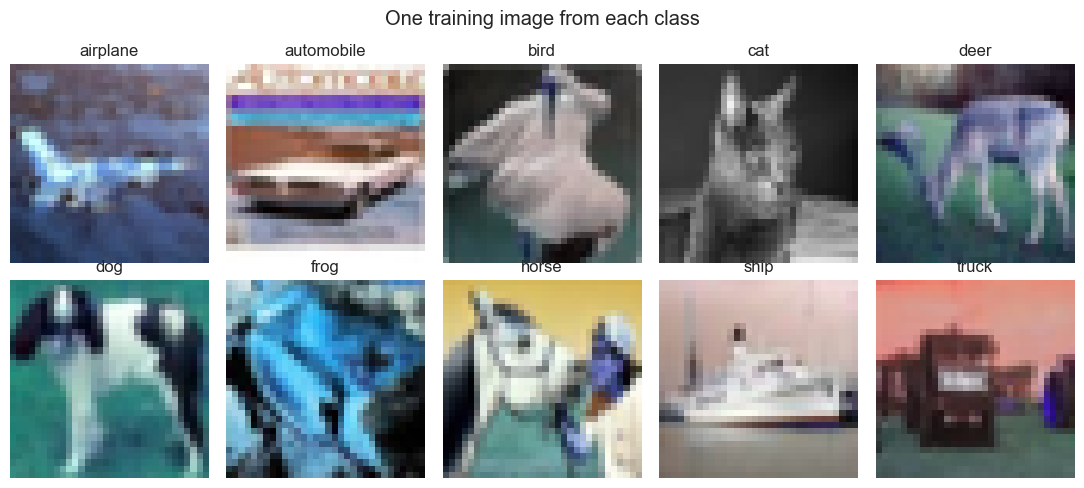

In [8]:
sample_indices = []
for class_number in range(10):
    sample_indices.append(np.flatnonzero(y_train == class_number)[0])

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for axis, index, class_name in zip(axes.ravel(), sample_indices, CLASS_NAMES):
    axis.imshow(x_train[index])
    axis.set_title(class_name)
    axis.axis("off")
plt.suptitle("One training image from each class")
plt.tight_layout()
plt.show()

## Training-only data augmentation

Horizontal flips and four-pixel reflected random crops are standard CIFAR-10 augmentation. They are applied only by the training dataset.

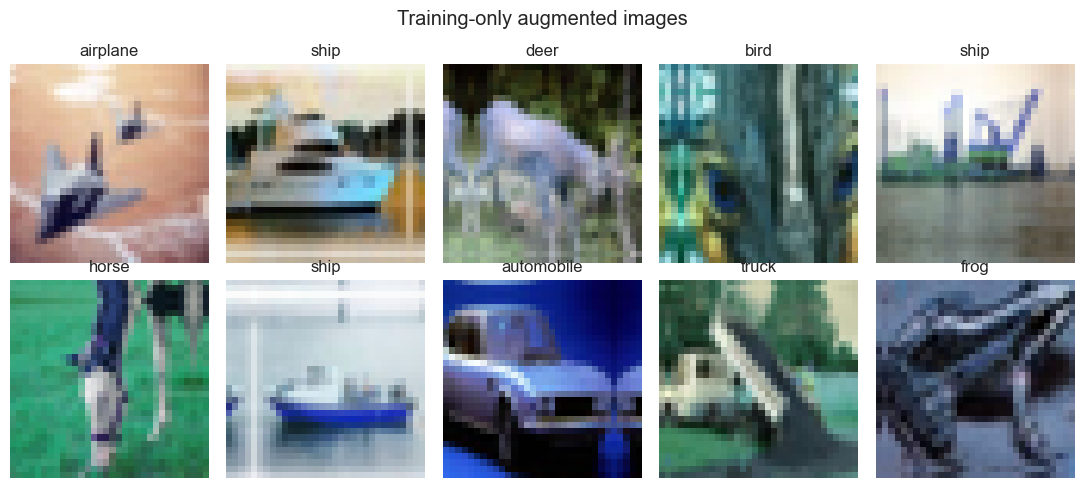

In [9]:
def augment_training_image(position, item):
    image, label = item
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.pad(image, [[4, 4], [4, 4], [0, 0]], mode="REFLECT")
    seed = tf.stack([tf.cast(SEED, tf.int32), tf.cast(position, tf.int32)])
    image = tf.image.stateless_random_crop(image, [32, 32, 3], seed=seed)
    image = tf.image.stateless_random_flip_left_right(image, seed=seed + [0, 1])
    return image, label


augmented_train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
augmented_train_dataset = augmented_train_dataset.shuffle(
    10000, seed=SEED, reshuffle_each_iteration=True
)
augmented_train_dataset = augmented_train_dataset.enumerate().map(
    augment_training_image,
    num_parallel_calls=AUTOTUNE,
    deterministic=True,
)
IMPROVED_BATCH_SIZE = 128
augmented_train_dataset = augmented_train_dataset.batch(IMPROVED_BATCH_SIZE).prefetch(AUTOTUNE)

augmented_batch, augmented_labels = next(iter(augmented_train_dataset))
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for axis, image, label in zip(axes.ravel(), augmented_batch[:10], augmented_labels[:10]):
    axis.imshow(tf.clip_by_value(image, 0, 1))
    axis.set_title(CLASS_NAMES[int(label)])
    axis.axis("off")
plt.suptitle("Training-only augmented images")
plt.tight_layout()
plt.show()

## Build the improved CNN

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

weight_decay = keras.regularizers.l2(1e-4)


def convolution_block(inputs, filters, dropout_rate, block_name):
    x = layers.Conv2D(
        filters, 3, padding="same", activation="relu",
        kernel_regularizer=weight_decay,
        name=f"{block_name}_conv1",
    )(inputs)
    x = layers.Conv2D(
        filters, 3, padding="same", use_bias=False,
        kernel_regularizer=weight_decay,
        name=f"{block_name}_conv2",
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn")(x)
    x = layers.Activation("relu", name=f"{block_name}_relu")(x)
    x = layers.MaxPooling2D(name=f"{block_name}_pool")(x)
    return layers.Dropout(dropout_rate, name=f"{block_name}_dropout")(x)


inputs = keras.Input(shape=(32, 32, 3), name="images")
x = convolution_block(inputs, 32, 0.20, "block1")
x = convolution_block(x, 64, 0.25, "block2")
x = convolution_block(x, 128, 0.30, "block3")
x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)
x = layers.Dense(256, use_bias=False, kernel_regularizer=weight_decay, name="dense")(x)
x = layers.BatchNormalization(name="dense_bn")(x)
x = layers.Activation("relu", name="dense_relu")(x)
x = layers.Dropout(0.40, name="dense_dropout")(x)
outputs = layers.Dense(10, activation="softmax", name="class_probabilities")(x)

improved_model = keras.Model(inputs, outputs, name="improved_cifar10_cnn")
assert improved_model.output_shape[-1] == 10
print("Improved three-block CNN created. Augmentation is supplied by the training dataset only.")

Improved three-block CNN created. Augmentation is supplied by the training dataset only.


## Model summary

In [11]:
improved_model.summary()

Model: "improved_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu (Activation)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu (Activation)        │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu (Activation)        │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_bn (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,042 (1.24 MB)

 Trainable params: 323,082 (1.23 MB)

 Non-trainable params: 960 (3.75 KB)

## Compile with the correct multiclass loss

In [12]:
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ],
)
print("Output units: 10, activation: softmax, loss: sparse categorical cross-entropy")

Output units: 10, activation: softmax, loss: sparse categorical cross-entropy


## Validation callbacks

Early stopping and learning-rate reduction monitor validation results only. The checkpoint stores the model with the best validation accuracy in the modern `.keras` format.

In [13]:
checkpoint_path = models_directory / "best_cifar10_improved.keras"
if checkpoint_path.exists():
    checkpoint_path.unlink()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=14,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

print("Callbacks monitor validation data only.")
print("Checkpoint: models/best_cifar10_improved.keras")

Callbacks monitor validation data only.
Checkpoint: models/best_cifar10_improved.keras


## Train the improved model

On CPU, this run may take about 30 to 90 minutes. The maximum is 70 epochs, but early stopping can finish sooner and restore the best validation model.

In [14]:
start_time = time.perf_counter()
history = improved_model.fit(
    augmented_train_dataset,
    validation_data=validation_dataset,
    epochs=70,
    callbacks=callbacks,
    verbose=2,
)
training_time = time.perf_counter() - start_time

print("Epochs trained:", len(history.history["loss"]))
print("Training time (seconds):", round(training_time, 2))
print("Best validation accuracy:", f"{max(history.history['val_accuracy']):.4f}")

Epoch 1/70



Epoch 1: val_accuracy improved from -inf to 0.10000, saving model to models/best_cifar10_improved.keras


313/313 - 120s - 382ms/step - accuracy: 0.4065 - loss: 1.6971 - top3_accuracy: 0.7529 - val_accuracy: 0.1000 - val_loss: 3.1727 - val_top3_accuracy: 0.4274 - learning_rate: 0.0010


Epoch 2/70



Epoch 2: val_accuracy improved from 0.10000 to 0.43520, saving model to models/best_cifar10_improved.keras


...

Epoch 70/70



Epoch 70: val_accuracy improved from 0.88920 to 0.89080, saving model to models/best_cifar10_improved.keras


313/313 - 113s - 361ms/step - accuracy: 0.8959 - loss: 0.3791 - top3_accuracy: 0.9861 - val_accuracy: 0.8908 - val_loss: 0.3922 - val_top3_accuracy: 0.9828 - learning_rate: 6.2500e-05


Restoring model weights from the end of the best epoch: 70.


Epochs trained: 70
Training time (seconds): 8196.57
Best validation accuracy: 0.8908


## Training curves

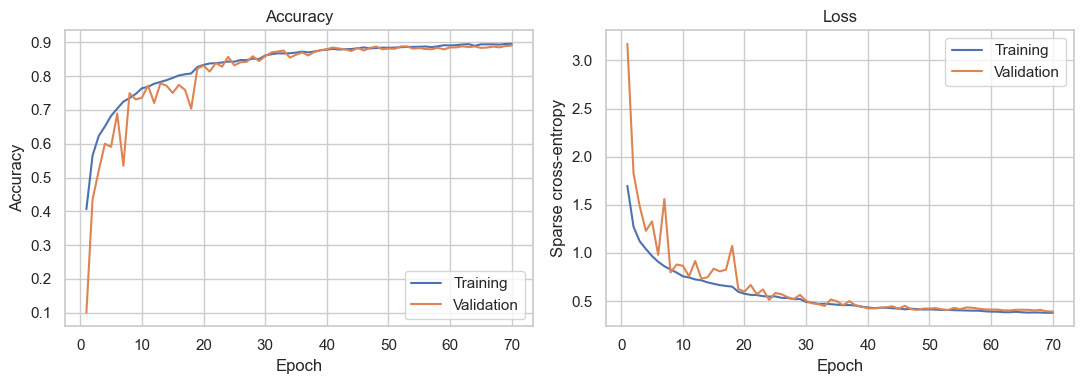

In [15]:
epochs = np.arange(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse cross-entropy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Load the best validation checkpoint

The checkpoint already exists because it was created during this training run. No test result is used to select it.

In [16]:
assert checkpoint_path.exists(), "The validation checkpoint was not created."
best_improved_model = keras.models.load_model(checkpoint_path)
print("Loaded: models/best_cifar10_improved.keras")

Loaded: models/best_cifar10_improved.keras


## Final evaluation on the locked test set

In [17]:
test_loss, test_accuracy, test_top3_accuracy = best_improved_model.evaluate(
    test_dataset, verbose=0
)
test_probabilities = best_improved_model.predict(test_dataset, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_confidences = np.max(test_probabilities, axis=1)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_predictions, average="macro", zero_division=0
)

print("IMPROVED TEST LOSS:", f"{test_loss:.4f}")
print("IMPROVED TEST ACCURACY:", f"{test_accuracy:.4f}")
print("IMPROVED TEST TOP-3 ACCURACY:", f"{test_top3_accuracy:.4f}")
print("IMPROVED MACRO PRECISION:", f"{macro_precision:.4f}")
print("IMPROVED MACRO RECALL:", f"{macro_recall:.4f}")
print("IMPROVED MACRO F1:", f"{macro_f1:.4f}")

IMPROVED TEST LOSS: 0.3817
IMPROVED TEST ACCURACY: 0.9008
IMPROVED TEST TOP-3 ACCURACY: 0.9824
IMPROVED MACRO PRECISION: 0.9011
IMPROVED MACRO RECALL: 0.9008
IMPROVED MACRO F1: 0.9006


## Classification report

In [18]:
print(classification_report(
    y_test,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
))

              precision    recall  f1-score   support

    airplane     0.9421    0.9120    0.9268       500
  automobile     0.9598    0.9540    0.9569       500
        bird     0.9041    0.8300    0.8655       500
         cat     0.7902    0.7760    0.7830       500
        deer     0.8990    0.8900    0.8945       500
         dog     0.8099    0.8520    0.8304       500
        frog     0.9336    0.9280    0.9308       500
       horse     0.8876    0.9320    0.9093       500
        ship     0.9402    0.9740    0.9568       500
       truck     0.9449    0.9600    0.9524       500

    accuracy                         0.9008      5000
   macro avg     0.9011    0.9008    0.9006      5000
weighted avg     0.9011    0.9008    0.9006      5000



## Confusion matrix

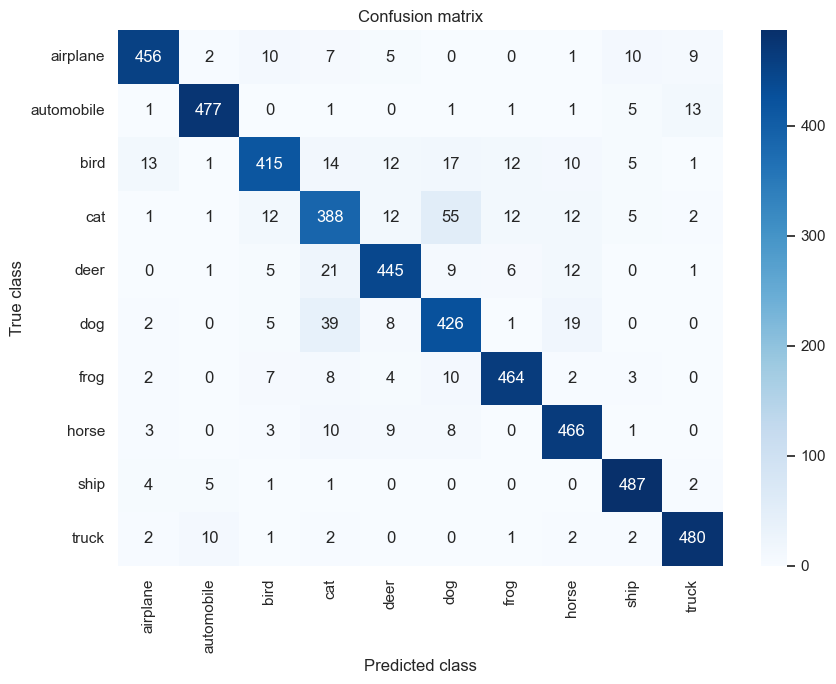

In [19]:
matrix = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Sample predictions

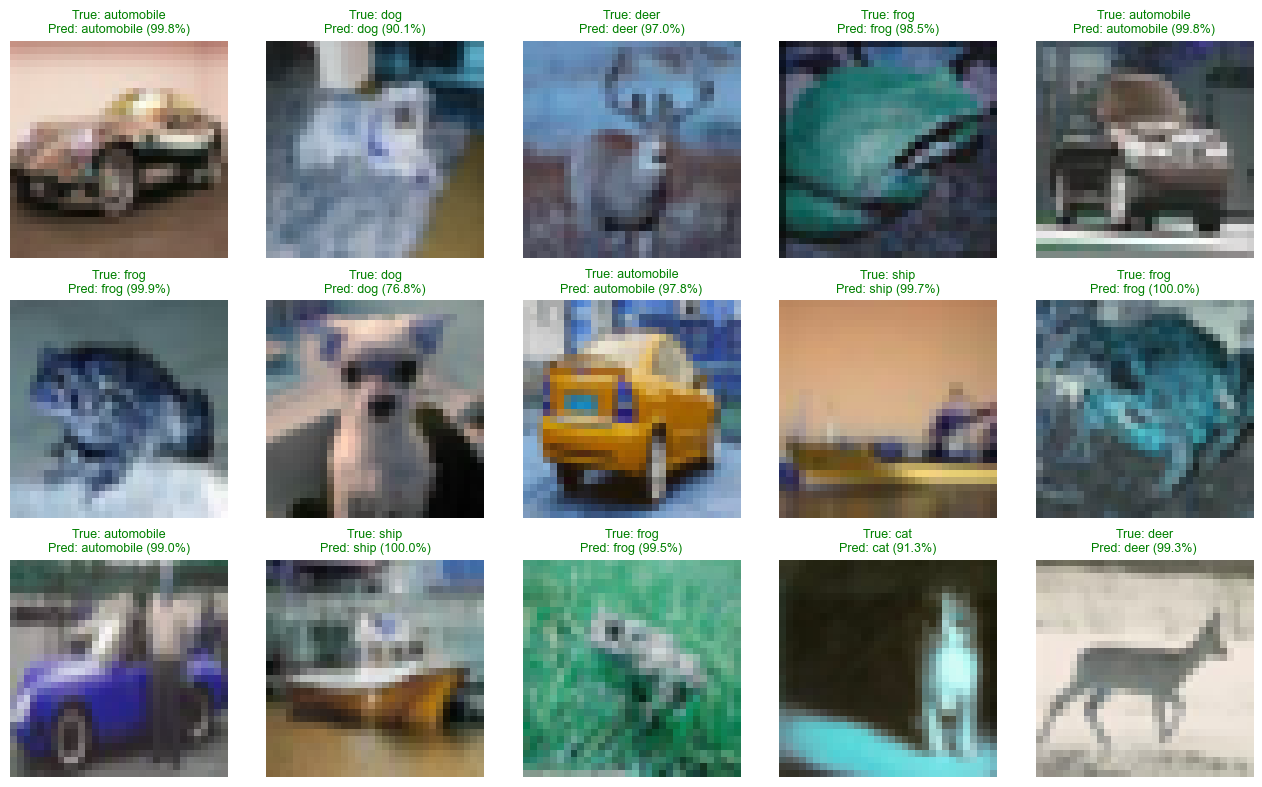

In [20]:
rng = np.random.default_rng(SEED)
display_indices = rng.choice(len(x_test), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(13, 8))
for axis, index in zip(axes.ravel(), display_indices):
    true_number = y_test[index]
    predicted_number = test_predictions[index]
    confidence = test_confidences[index]
    correct = true_number == predicted_number
    axis.imshow(x_test[index])
    axis.set_title(
        f"True: {CLASS_NAMES[true_number]}\n"
        f"Pred: {CLASS_NAMES[predicted_number]} ({confidence:.1%})",
        color="green" if correct else "red",
        fontsize=9,
    )
    axis.axis("off")
plt.tight_layout()
plt.show()

## High-confidence mistakes

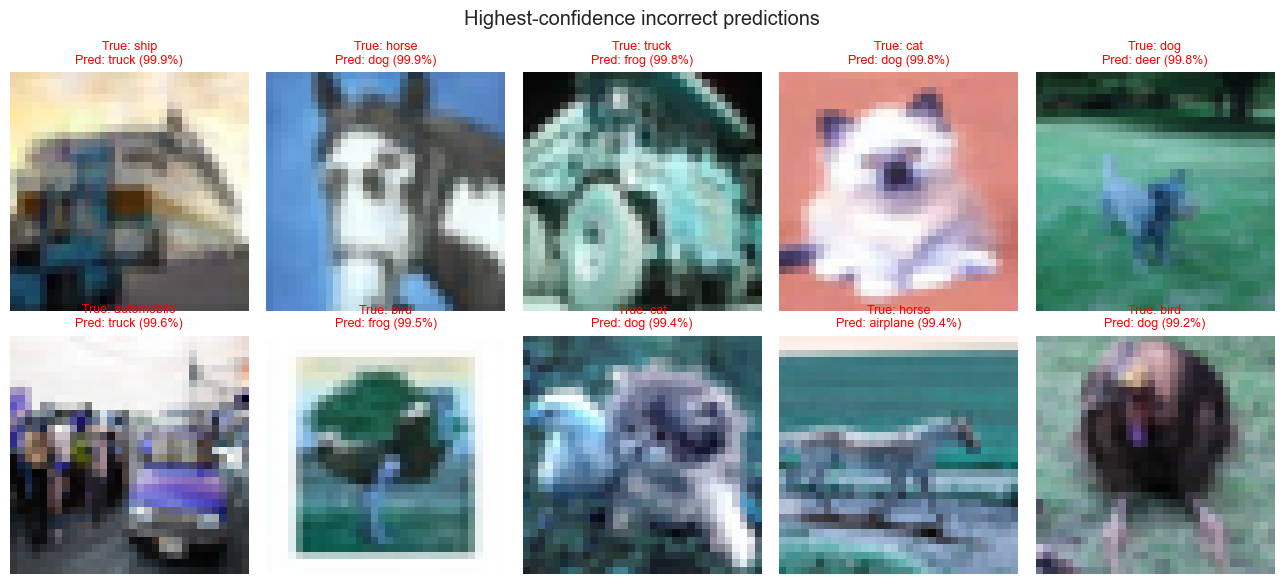

In [21]:
mistake_indices = np.flatnonzero(test_predictions != y_test)
ranked_mistakes = mistake_indices[np.argsort(test_confidences[mistake_indices])[::-1]]
mistake_display = ranked_mistakes[:10]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for axis, index in zip(axes.ravel(), mistake_display):
    axis.imshow(x_test[index])
    axis.set_title(
        f"True: {CLASS_NAMES[y_test[index]]}\n"
        f"Pred: {CLASS_NAMES[test_predictions[index]]} ({test_confidences[index]:.1%})",
        color="red",
        fontsize=9,
    )
    axis.axis("off")
plt.suptitle("Highest-confidence incorrect predictions")
plt.tight_layout()
plt.show()

## Save metrics and compare both CNNs

In [22]:
improved_metrics = {
    "model_name": "Improved CNN with callbacks",
    "architecture": "Three regularized double-convolution blocks with augmentation and callbacks",
    "parameter_count": int(best_improved_model.count_params()),
    "best_validation_accuracy": float(max(history.history["val_accuracy"])),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "top3_accuracy": float(test_top3_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "epochs_trained": int(len(history.history["loss"])),
    "training_time_seconds": float(training_time),
    "saved_model": "models/best_cifar10_improved.keras",
}

with (results_directory / "improved_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(improved_metrics, file, indent=2)

baseline_path = results_directory / "baseline_metrics.json"
if baseline_path.exists():
    with baseline_path.open("r", encoding="utf-8") as file:
        baseline_metrics = json.load(file)
    comparison_columns = [
        "model_name", "parameter_count", "best_validation_accuracy",
        "test_accuracy", "macro_f1", "epochs_trained", "training_time_seconds",
    ]
    comparison = pd.DataFrame([baseline_metrics, improved_metrics])[comparison_columns]
    display(comparison.round(4))
else:
    print("Baseline metrics are missing. Run the baseline notebook to add its comparison row.")

print("Saved: results/improved_metrics.json")

,model_name,parameter_count,best_validation_accuracy,test_accuracy,macro_f1,epochs_trained,training_time_seconds
0,Baseline CNN,356810,0.7428,0.7292,0.7304,25,799.8134
1,Improved CNN with callbacks,324042,0.8908,0.9008,0.9006,70,8196.5723


Saved: results/improved_metrics.json


## Conclusion

The improved CNN uses augmentation only during training and selects its checkpoint with validation accuracy. Batch normalization, dropout, L2 regularization, and learning-rate reduction help the deeper model generalize. The locked test set is used only for the final report.